## **Comparative Analysis of Machine Learning Models for Near-Earth Object Hazard Classification**

**Author:** Brian Urban 

**Affiliation:** Jarvis College of Computing and Digital Media, DePaul University

<br>

---

#### **1. Environment Setup and Reproducibility**

This section imports the core Python libraries used in this project:

- `pandas` for loading, exploring, and manipulating tabular data.

- `scikit-learn` for preprocessing, dataset splitting, metrics, and baseline models (including ensemble methods: Random Forest, Gradient Boosting and Stacking).

- `imbalanced-learn` for Synthetic Minority Over-sampling Technique (SMOTE) to address class imbalance.

- `matplotlib` is used to plot training curves, confusion matrices, and ROC curves.

- `torch` for implementing and training the neural network models.

- `numpy` for numerical operations and array manipulation.

All random seeds are fixed for full reproducibility across experiments.

In [1]:
# =============================================================================
# IMPORTING LIBRARIES
# =============================================================================
# STANDARD LIBRARY
import copy
import time
import warnings

# NUMERIC & DATA SCIENCE
import numpy as np
import pandas as pd

# VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# SCIKIT-LEARN
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    auc as sk_auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    f1_score,
    fbeta_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# IMBALANCED-LEARN
from imblearn.over_sampling import SMOTE

# PYTORCH
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# =============================================================================
# SET ALL SEEDS
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

<br>

---

#### **2. Data Pipeline and Preprocessing Framework**

The preprocessing pipeline loads the NEO dataset and quantifies the severe class imbalance inherent in planetary hazard detection. The experiment uses a 70/15/15 stratified split for training, validation, and test sets, respectively, ensuring consistent class ratios across all partitions. A naive baseline model (always predicting "safe") establishes the minimum acceptable performance—achieving 87.24% accuracy simply by exploiting the class distribution, demonstrating why accuracy alone is misleading for this task.

SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training set to synthetically balance the classes, preventing models from learning trivial "predict safe" heuristics. Numeric features are standardized within the training split only to prevent data leakage. Finally, PyTorch DataLoaders are constructed with a batch size of 512 for efficient mini-batch training.

In [2]:
# ============================================================
# LOAD AND PREPARE DATA
# ============================================================
try:
    df = pd.read_csv("nearest-earth-objects(1910-2024).csv")
except FileNotFoundError:
    print("ERROR: Dataset file not found.")
    print("Download from Kaggle:")
    print("https://www.kaggle.com/datasets/ivansher/nasa-nearest-earth-objects-1910-2024")
    raise

print("Shape:", df.shape, "\n")
print("Columns:", df.columns, "\n")
print(df.head())

Shape: (338199, 9) 

Columns: Index(['neo_id', 'name', 'absolute_magnitude', 'estimated_diameter_min',
       'estimated_diameter_max', 'orbiting_body', 'relative_velocity',
       'miss_distance', 'is_hazardous'],
      dtype='str') 

    neo_id                name  absolute_magnitude  estimated_diameter_min  \
0  2162117  162117 (1998 SD15)               19.14                0.394962   
1  2349507    349507 (2008 QY)               18.50                0.530341   
2  2455415    455415 (2003 GA)               21.45                0.136319   
3  3132126           (2002 PB)               20.63                0.198863   
4  3557844           (2011 DW)               22.70                0.076658   

   estimated_diameter_max orbiting_body  relative_velocity  miss_distance  \
0                0.883161         Earth       71745.401048   5.814362e+07   
1                1.185878         Earth      109949.757148   5.580105e+07   
2                0.304818         Earth       24865.506798   6.7

Class counts: is_hazardous
False    295037
True      43162
Name: count, dtype: int64 

Class %: is_hazardous
False    87.238
True     12.762
Name: count, dtype: float64 

Imbalance ratio (majority/minority): 6.84


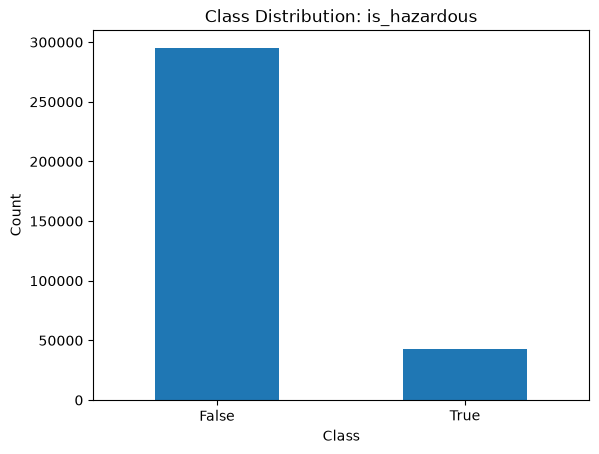

In [3]:
# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================
target = "is_hazardous"
counts = df[target].value_counts(dropna=False)
pct = (counts / len(df) * 100).round(3)
imbalance_ratio = counts.max() / counts.min()

print("Class counts:", counts, "\n")
print("Class %:", pct, "\n")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

counts.plot(kind="bar")
plt.title("Class Distribution: is_hazardous")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [4]:
# ============================================================
# STRATIFIED SPLIT
# ============================================================
X = df.drop(columns=[target, 'neo_id'])
y = df[target].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, 
    stratify=y_temp
)

for name, y_s in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    c = y_s.value_counts()
    print(f"{name}: n={len(y_s)} | class counts: {dict(c)} | hazardous%: {c.get(1, 0) / len(y_s) * 100:.2f}%")


Train: n=236739 | class counts: {0: np.int64(206526), 1: np.int64(30213)} | hazardous%: 12.76%
Val: n=50730 | class counts: {0: np.int64(44255), 1: np.int64(6475)} | hazardous%: 12.76%
Test: n=50730 | class counts: {0: np.int64(44256), 1: np.int64(6474)} | hazardous%: 12.76%


In [5]:
# ============================================================
# BASELINE MODEL (ALWAYS-ZERO)
# ============================================================
y_pred_all_zero = np.zeros_like(y_test)
print(f"Accuracy (always non-hazardous): {accuracy_score(y_test, y_pred_all_zero):.4f}")
print(confusion_matrix(y_test, y_pred_all_zero))
print(classification_report(
    y_test,
    y_pred_all_zero,
    target_names=["Non-Hazardous", "Hazardous"],
    digits=4,
    zero_division=0
))

Accuracy (always non-hazardous): 0.8724
[[44256     0]
 [ 6474     0]]
               precision    recall  f1-score   support

Non-Hazardous     0.8724    1.0000    0.9318     44256
    Hazardous     0.0000    0.0000    0.0000      6474

     accuracy                         0.8724     50730
    macro avg     0.4362    0.5000    0.4659     50730
 weighted avg     0.7611    0.8724    0.8129     50730



In [6]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================
missing_rate = df.isna().mean().sort_values(ascending=False)
print(f"Missingness:\n{missing_rate}")

numeric_cols = df.select_dtypes(include="number").columns
group_means = df.groupby(target)[numeric_cols].mean(numeric_only=True)
print(f"\nFeature means by class:\n{group_means}")

Missingness:
absolute_magnitude        0.000083
estimated_diameter_max    0.000083
estimated_diameter_min    0.000083
neo_id                    0.000000
name                      0.000000
orbiting_body             0.000000
relative_velocity         0.000000
miss_distance             0.000000
is_hazardous              0.000000
dtype: float64

Feature means by class:
                    neo_id  absolute_magnitude  estimated_diameter_min  \
is_hazardous                                                             
False         1.897066e+07           23.315579                0.138021   
True          8.225991e+06           20.314378                0.293083   

              estimated_diameter_max  relative_velocity  miss_distance  
is_hazardous                                                            
False                       0.308624       49172.265510   4.158731e+07  
True                        0.655353       63968.941094   4.118015e+07  


In [7]:
# ============================================================
# SMOTE OVERSAMPLING
# ============================================================
X_train_num = X_train.select_dtypes(include="number").copy()
imputer = SimpleImputer(strategy="median")
X_train_num_imp = imputer.fit_transform(X_train_num)
smote = SMOTE(random_state=RANDOM_SEED)
X_res, y_res = smote.fit_resample(X_train_num_imp, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After SMOTE: {dict(pd.Series(y_res).value_counts())}")

Before SMOTE: {0: np.int64(206526), 1: np.int64(30213)}
After SMOTE: {0: np.int64(206526), 1: np.int64(206526)}


In [8]:
# ============================================================
# FEATURE SCALING
# ============================================================
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
X_val_num  = imputer.transform(X_val[numeric_cols])
X_test_num = imputer.transform(X_test[numeric_cols])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_res)
X_val_scaled   = scaler.transform(X_val_num)
X_test_scaled  = scaler.transform(X_test_num)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Val shape: {X_val_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")
print(f"Features: {numeric_cols}")

Train shape: (413052, 5)
Val shape: (50730, 5)
Test shape: (50730, 5)
Features: ['absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'relative_velocity', 'miss_distance']


In [9]:
# ============================================================
# PYTORCH DATALOADERS
# ============================================================
def to_tensors(X, y):
    """Convert numpy arrays to float32 PyTorch TensorDataset."""
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values if hasattr(y, "values") else y, dtype=torch.float32)
    return TensorDataset(X_t, y_t)

BATCH_SIZE = 512
train_ds = to_tensors(X_train_scaled, y_res)
val_ds = to_tensors(X_val_scaled, y_val)
test_ds = to_tensors(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 807
Val batches: 100
Test batches: 100


<br>

---

#### **3. Model Architecture and Training Configuration**

Two deep learning architectures are implemented for comparative evaluation: a residual Deep Neural Network (NEO_DNN) with skip connections designed to mitigate vanishing gradients and a standard Multi-Layer Perceptron (NEO_MLP) trained on an engineered feature set for ablation comparison. Both models use Focal Loss rather than binary cross-entropy to prioritize minority-class (hazardous) examples during training, with cosine annealing learning rate scheduling for smooth convergence.

A shared evaluation helper function is provided for classical sklearn models, enabling consistent threshold tuning on the validation set and test set reporting across all models.

In [10]:
# ============================================================
# RESIDUAL BLOCK ARCHITECTURE
# ============================================================
class ResBlock(nn.Module):
    """
    Residual block: Linear → BatchNorm → LeakyReLU → Dropout,
    with a skip connection (identity if dims match, else linear projection).

    Args:
        in_dim (int): Input feature dimensionality.
        out_dim (int): Output feature dimensionality.
        dropout (float): Dropout rate (default: 0.2).

    Note:
        Skip connections allow gradients to flow more easily during
        backpropagation, mitigating vanishing gradients in deeper networks.
    """
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.05),
            nn.Dropout(dropout)
        )
        
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)

In [11]:
# ============================================================
# NEO_DNN ARCHITECTURE
# ============================================================
class NEO_DNN(nn.Module):
    """
    Residual Deep Neural Network for NEO hazard binary classification.

    Architecture:
        Input → BatchNorm
              → ResBlock(input_dim → 512, drop=0.25)
              → ResBlock(512 → 256, drop=0.25)
              → ResBlock(256 → 128, drop=0.20)
              → ResBlock(128 →  64, drop=0.10)
              → Linear(64 → 1)  [raw logit]

    Args:
        input_dim (int): Number of input features.

    Total parameters (input_dim=5): 353,099
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.bn_input = nn.BatchNorm1d(input_dim)
        self.rb1 = ResBlock(input_dim, 512, dropout=0.25)
        self.rb2 = ResBlock(512, 256, dropout=0.25)
        self.rb3 = ResBlock(256, 128, dropout=0.20)
        self.rb4 = ResBlock(128, 64, dropout=0.10)
        self.output = nn.Linear(64, 1)
    
    def forward(self, x):
        x = self.bn_input(x)
        x = self.rb1(x)
        x = self.rb2(x)
        x = self.rb3(x)
        x = self.rb4(x)
        return self.output(x).squeeze(1)

INPUT_DIM = X_train_scaled.shape[1]
model = NEO_DNN(input_dim=INPUT_DIM)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

NEO_DNN(
  (bn_input): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (rb1): ResBlock(
    (block): Sequential(
      (0): Linear(in_features=5, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
      (3): Dropout(p=0.25, inplace=False)
    )
    (skip): Linear(in_features=5, out_features=512, bias=True)
  )
  (rb2): ResBlock(
    (block): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
      (3): Dropout(p=0.25, inplace=False)
    )
    (skip): Linear(in_features=512, out_features=256, bias=True)
  )
  (rb3): ResBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, mome

In [12]:
# ============================================================
# FOCAL LOSS
# ============================================================
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance in binary classification.

    Down-weights easy (confident, correct) predictions so the model
    focuses training on hard, ambiguous samples — critical for improving
    minority-class (hazardous) recall.

    Args:
        alpha (float): Weight for the positive (hazardous) class.
                       Set > 0.5 to penalize false-negatives more. Default: 0.75.
        gamma (float): Focusing exponent. Higher γ → more focus on hard
                       examples. Default: 2.0.

    Formula:
        FL = -alpha * (1 - p_t)^gamma * log(p_t)

    Reference:
        Lin et al., "Focal Loss for Dense Object Detection", ICCV 2017.
        https://doi.org/10.1109/ICCV.2017.324
    """
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 5e-4
EPOCHS = 120
PATIENCE = 12

model = model.to(DEVICE)
criterion = FocalLoss(alpha=0.45, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f"Device: {DEVICE}")
print("Criterion: FocalLoss(alpha=0.45, gamma=2.0)")
print(f"Optimizer: Adam  lr={LR}, weight_decay=1e-4")
print("Scheduler: CosineAnnealingLR")

Device: cpu
Criterion: FocalLoss(alpha=0.45, gamma=2.0)
Optimizer: Adam  lr=0.0005, weight_decay=1e-4
Scheduler: CosineAnnealingLR


In [13]:
# ============================================================
# SHARED SKLEARN EVALUATION HELPER
# ============================================================
def eval_sklearn_model(name, clf, X_tr, y_tr, X_v, y_v, X_te, y_te,
                       tune_threshold=True):
    """
    Fit a classifier, tune the decision threshold on the validation set
    for recall-biased performance, then evaluate on the held-out test set.

    The threshold search uses a harmonic mean of recall and F1 as the
    scoring objective, which balances recall against precision without
    letting either dominate.

    Args:
        name (str): Display name for the model.
        clf: A scikit-learn estimator implementing fit() and predict_proba().
        X_tr, y_tr: Training features and labels (SMOTE-balanced, scaled).
        X_v, y_v: Validation features and labels (original distribution, scaled).
        X_te, y_te: Test features and labels (original distribution, scaled).
        tune_threshold (bool): If True, search thresholds on validation set.
                               If False, use default 0.5 threshold.

    Returns:
        tuple: (fitted_classifier, best_threshold)
    """
    clf.fit(X_tr, y_tr)

    if tune_threshold and hasattr(clf, "predict_proba"):
        val_probs = clf.predict_proba(X_v)[:, 1]
        thresholds = np.linspace(0.10, 0.70, 121)
        scores = []
        for t in thresholds:
            preds = (val_probs >= t).astype(int)
            rec = recall_score(y_v, preds, pos_label=1, zero_division=0)
            f1 = f1_score(y_v, preds, pos_label=1, zero_division=0)
            scores.append(2 * rec * f1 / (rec + f1) if (rec + f1) > 0 else 0)
        
        best_t = thresholds[np.argmax(scores)]
        test_probs = clf.predict_proba(X_te)[:, 1]
        test_preds = (test_probs >= best_t).astype(int)
        auc = roc_auc_score(y_te, test_probs)
        print(f"\n{'='*90}")
        print(f"{name} | threshold={best_t:.2f} | AUC={auc:.4f}")
        print(f"{'='*90}")
    else:
        test_preds = clf.predict(X_te)
        best_t = 0.5
        print(f"\n{'='*86}")
        print(f"{name}")
        print(f"{'='*86}")

    print(classification_report(
        y_te, 
        test_preds,
        target_names=["Non-Hazardous", "Hazardous"], 
        digits=4,
        zero_division=0,
    ))
    return clf, best_t

print("eval_sklearn_model defined.")

eval_sklearn_model defined.


<br>

---

#### **4. Experiment 1: Residual DNN Training and Evaluation**

The residual DNN is trained for up to 120 epochs with early stopping (patience=12) based on validation loss. Gap-penalized threshold tuning is applied to the validation set to balance hazardous and non-hazardous recalls within 2 percentage points, pushing the decision threshold upward rather than allowing hazardous recall to dominate. The final evaluation occurs on the held-out test set using the tuned threshold.

In [14]:
# ============================================================
# TRAINING LOOP
# ============================================================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

history = {"train_loss": [], "val_loss": [], "val_auc": []}
best_val_loss  = float("inf")
best_weights   = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    val_probs = []
    val_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(X_batch)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_ds)
    val_auc = roc_auc_score(val_labels, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    scheduler.step(val_loss)
    elapsed = time.time() - t0

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_AUC={val_auc:.4f} ({elapsed:.1f}s)")

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

model.load_state_dict(best_weights)
print(f"Best val loss: {best_val_loss:.4f}")

Epoch   1/120 train_loss=0.0417 val_loss=0.0422 val_AUC=0.8797 (29.1s)
Epoch   5/120 train_loss=0.0369 val_loss=0.0395 val_AUC=0.8806 (29.5s)
Epoch  10/120 train_loss=0.0339 val_loss=0.0759 val_AUC=0.8597 (32.6s)
Early stopping at epoch 14 (no improvement for 12 epochs).
Best val loss: 0.0352


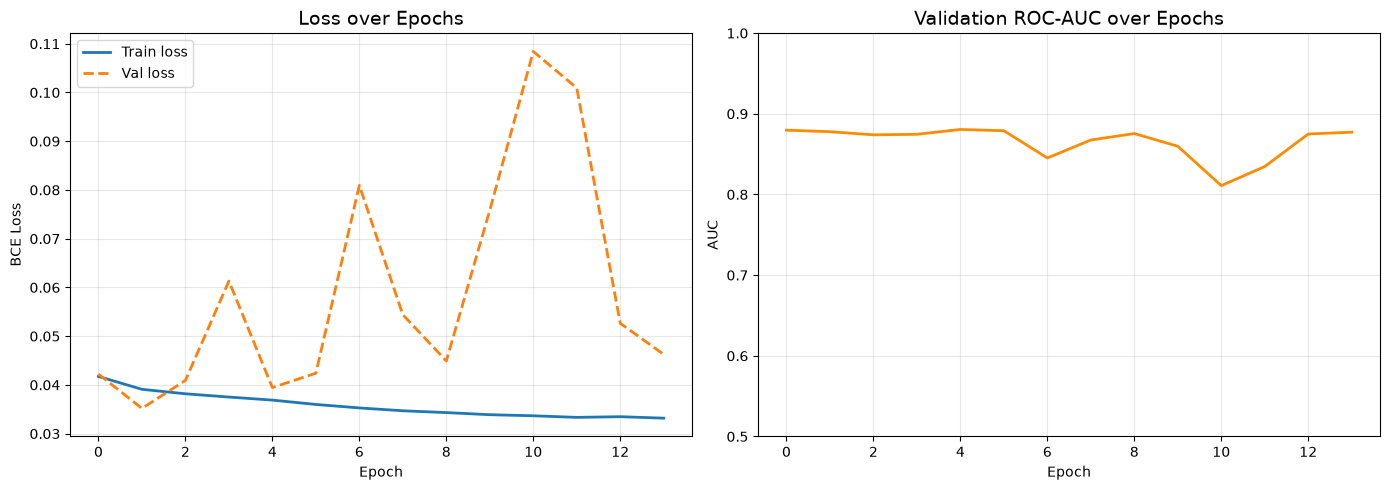

In [15]:
# ============================================================
# TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val loss", linewidth=2, linestyle="--")
axes[0].set_title("Loss over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_auc"], color="darkorange", linewidth=2)
axes[1].set_title("Validation ROC-AUC over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# GAP-PENALIZED THRESHOLD TUNING
# ============================================================
test_probs  = []
test_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

val_probs_arr = np.array(val_probs)
val_labels_arr = np.array(val_labels)

thresholds = np.linspace(0.10, 0.95, 171)
scores = []
for t in thresholds:
    preds = (val_probs_arr >= t).astype(int)
    rec_hazardous = recall_score(val_labels_arr, preds, pos_label=1, zero_division=0)
    rec_non_hazardous = recall_score(val_labels_arr, preds, pos_label=0, zero_division=0)
    balanced_acc = (rec_hazardous + rec_non_hazardous) / 2.0
    gap = max(0.0, rec_hazardous - rec_non_hazardous - 0.02)
    scores.append(balanced_acc - 2.0 * gap ** 2)

best_thresh = thresholds[np.argmax(scores)]
print(f"Best decision threshold (gap-penalized balanced accuracy): {best_thresh:.2f}")

val_preds_diagnostic = (val_probs_arr >= best_thresh).astype(int)
print(f"  Val non-hazardous recall: {recall_score(val_labels_arr, val_preds_diagnostic, pos_label=0):.4f}")
print(f"  Val hazardous recall: {recall_score(val_labels_arr, val_preds_diagnostic, pos_label=1):.4f}")


test_preds = (test_probs >= best_thresh).astype(int)
test_auc = roc_auc_score(test_labels, test_probs)
print(f"\nTest ROC-AUC : {test_auc:.4f}")
print("\nClassification Report (NEO_DNN — Residual + Focal Loss):")
print(classification_report(test_labels, test_preds,
                            target_names=["Non-Hazardous", "Hazardous"],
                            digits=4))

Best decision threshold (gap-penalized balanced accuracy): 0.51
  Val non-hazardous recall: 0.7683
  Val hazardous recall: 0.8408

Test ROC-AUC : 0.8743

Classification Report (NEO_DNN — Residual + Focal Loss):
               precision    recall  f1-score   support

Non-Hazardous     0.9510    0.8128    0.8765     44256
    Hazardous     0.3580    0.7135    0.4768      6474

     accuracy                         0.8001     50730
    macro avg     0.6545    0.7631    0.6766     50730
 weighted avg     0.8753    0.8001    0.8255     50730



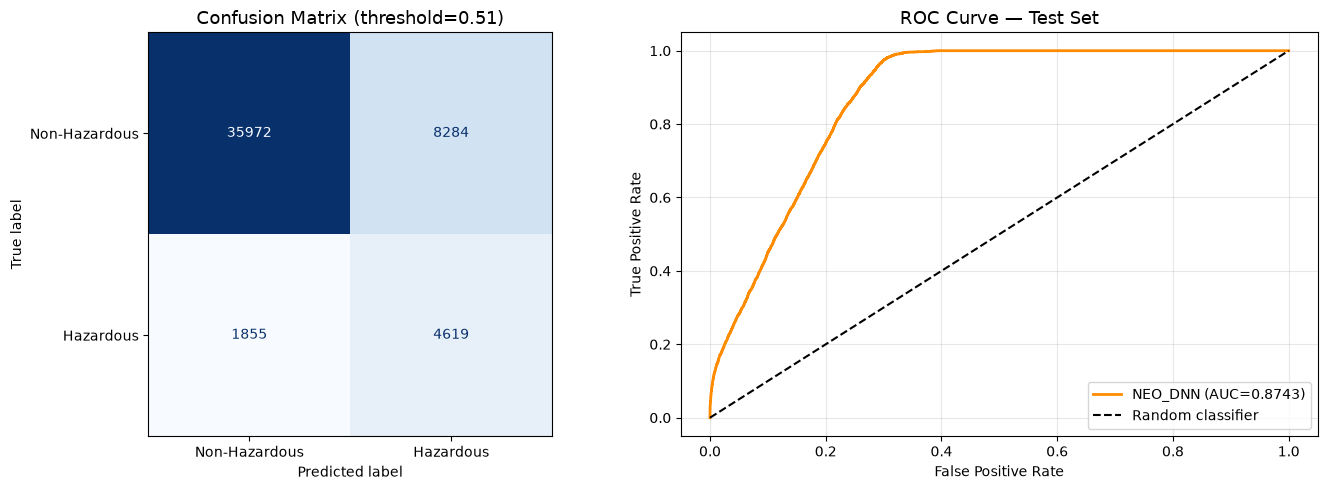

In [17]:
# ============================================================
# CONFUSION MATRIX & ROC CURVE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c_m = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=c_m,
                              display_labels=["Non-Hazardous", "Hazardous"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix (threshold={best_thresh:.2f})", fontsize=13)


fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = sk_auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="darkorange", linewidth=2,
             label=f"NEO_DNN (AUC={roc_auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[1].set_title("ROC Curve — Test Set", fontsize=13)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<br>

---

#### **5. Experiment 2: Classical Machine Learning Models**

Seven scikit-learn classifiers plus a Stacking Ensemble are evaluated on the same SMOTE-balanced feature set used for the DNN. Each model is configured with `class_weight='balanced'` or `'balanced_subsample'` to account for the original class distribution, and thresholds are tuned on the validation set using recall-biased objectives.

In [18]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================
lr_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000, C=0.5,    # mild L2 regularization
    solver="lbfgs",
    random_state=RANDOM_SEED)

lr_clf, lr_thresh = eval_sklearn_model(
    "Logistic Regression (balanced weights)",
    lr_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


Logistic Regression (balanced weights) | threshold=0.42 | AUC=0.8384
               precision    recall  f1-score   support

Non-Hazardous     0.9878    0.6796    0.8052     44256
    Hazardous     0.3009    0.9425    0.4561      6474

     accuracy                         0.7131     50730
    macro avg     0.6443    0.8111    0.6307     50730
 weighted avg     0.9001    0.7131    0.7607     50730



In [19]:
# ============================================================
# DECISION TREE
# ============================================================
dt_clf = DecisionTreeClassifier(
    max_depth=12,
    class_weight="balanced",
    min_samples_leaf=10,
    random_state=RANDOM_SEED)
    
dt_clf, dt_thresh = eval_sklearn_model(
    "Decision Tree (balanced, max_depth=12)",
    dt_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


Decision Tree (balanced, max_depth=12) | threshold=0.20 | AUC=0.8813
               precision    recall  f1-score   support

Non-Hazardous     0.9949    0.7106    0.8290     44256
    Hazardous     0.3302    0.9753    0.4933      6474

     accuracy                         0.7444     50730
    macro avg     0.6626    0.8429    0.6612     50730
 weighted avg     0.9101    0.7444    0.7862     50730



In [20]:
# ============================================================
# RANDOM FOREST
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced_subsample",
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_SEED)
    
rf_clf, rf_thresh = eval_sklearn_model(
    "Random Forest (balanced_subsample, 300 trees)",
    rf_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


Random Forest (balanced_subsample, 300 trees) | threshold=0.26 | AUC=0.9422
               precision    recall  f1-score   support

Non-Hazardous     0.9791    0.8568    0.9139     44256
    Hazardous     0.4719    0.8750    0.6132      6474

     accuracy                         0.8591     50730
    macro avg     0.7255    0.8659    0.7635     50730
 weighted avg     0.9144    0.8591    0.8755     50730



In [21]:
# ============================================================
# GAUSSIAN NAÏVE BAYES
# ============================================================
gnb_clf = GaussianNB()

gnb_clf, gnb_thresh = eval_sklearn_model(
    "Gaussian Naïve Bayes",
    gnb_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


Gaussian Naïve Bayes | threshold=0.40 | AUC=0.8281
               precision    recall  f1-score   support

Non-Hazardous     0.9898    0.6790    0.8055     44256
    Hazardous     0.3026    0.9523    0.4593      6474

     accuracy                         0.7139     50730
    macro avg     0.6462    0.8156    0.6324     50730
 weighted avg     0.9021    0.7139    0.7613     50730



In [22]:
# ============================================================
# K-NEAREST NEIGHBORS
# ============================================================
knn_clf = KNeighborsClassifier(
    n_neighbors=7, weights="distance", n_jobs=-1)

knn_clf, knn_thresh = eval_sklearn_model(
    "K-Nearest Neighbors (k=7, distance-weighted)",
    knn_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


K-Nearest Neighbors (k=7, distance-weighted) | threshold=0.40 | AUC=0.8993
               precision    recall  f1-score   support

Non-Hazardous     0.9792    0.7836    0.8705     44256
    Hazardous     0.3747    0.8865    0.5267      6474

     accuracy                         0.7967     50730
    macro avg     0.6770    0.8350    0.6986     50730
 weighted avg     0.9021    0.7967    0.8267     50730



In [23]:
# ============================================================
# GRADIENT BOOSTING
# ============================================================
hgb_clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight="balanced",
    random_state=RANDOM_SEED)

hgb_clf, hgb_thresh = eval_sklearn_model(
    "HistGradientBoosting (balanced, lr=0.05)",
    hgb_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


HistGradientBoosting (balanced, lr=0.05) | threshold=0.43 | AUC=0.8936
               precision    recall  f1-score   support

Non-Hazardous     0.9906    0.7311    0.8413     44256
    Hazardous     0.3414    0.9527    0.5026      6474

     accuracy                         0.7594     50730
    macro avg     0.6660    0.8419    0.6720     50730
 weighted avg     0.9078    0.7594    0.7981     50730



In [24]:
# ============================================================
# SUPPORT VECTOR MACHINE
# ============================================================
base_svc = LinearSVC(
    class_weight="balanced",
    max_iter=2000,
    C=0.1,
    random_state=RANDOM_SEED)

svm_clf = CalibratedClassifierCV(base_svc, cv=3)
svm_clf, svm_thresh = eval_sklearn_model(
    "Linear SVM — Calibrated (balanced, C=0.1)",
    svm_clf, X_train_scaled, y_res,
    X_val_scaled, y_val,
    X_test_scaled, y_test)


Linear SVM — Calibrated (balanced, C=0.1) | threshold=0.42 | AUC=0.8384
               precision    recall  f1-score   support

Non-Hazardous     0.9877    0.6775    0.8037     44256
    Hazardous     0.2994    0.9422    0.4544      6474

     accuracy                         0.7113     50730
    macro avg     0.6436    0.8099    0.6291     50730
 weighted avg     0.8998    0.7113    0.7591     50730



In [25]:
# ============================================================
# STACKING ENSEMBLE
# ============================================================
estimators = [
    ("lr", LogisticRegression(class_weight="balanced", 
    max_iter=1000, C=0.5, solver="lbfgs", 
    random_state=RANDOM_SEED)),
    ("rf", RandomForestClassifier(n_estimators=200, 
    class_weight="balanced_subsample", min_samples_leaf=5, 
    n_jobs=-1, random_state=RANDOM_SEED)),
    ("hgb", HistGradientBoostingClassifier(max_iter=200, 
    learning_rate=0.05, max_depth=6, class_weight="balanced",
    random_state=RANDOM_SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=7, 
    weights="distance", n_jobs=-1)),
    ("svm", CalibratedClassifierCV(LinearSVC(
    class_weight="balanced", max_iter=2000,
    C=0.1, random_state=RANDOM_SEED), cv=3))
]
meta = LogisticRegression(class_weight="balanced", 
    max_iter=500, random_state=RANDOM_SEED)

stack_clf = StackingClassifier(estimators=estimators,
    final_estimator=meta, cv=5, stack_method="predict_proba",
    n_jobs=-1, passthrough=False)
print("Training Stacking Ensemble (this may take a few minutes)...")
stack_clf, stack_thresh = eval_sklearn_model(
    "Stacking Ensemble (LR + RF + HGB + KNN + SVM → LR meta)",
    stack_clf, X_train_scaled, y_res, X_val_scaled, y_val,
    X_test_scaled, y_test)

Training Stacking Ensemble (this may take a few minutes)...

Stacking Ensemble (LR + RF + HGB + KNN + SVM → LR meta) | threshold=0.28 | AUC=0.9390
               precision    recall  f1-score   support

Non-Hazardous     0.9812    0.8374    0.9036     44256
    Hazardous     0.4448    0.8905    0.5933      6474

     accuracy                         0.8442     50730
    macro avg     0.7130    0.8639    0.7484     50730
 weighted avg     0.9128    0.8442    0.8640     50730



<br>

---

#### **6. Experiment 3: Feature Engineering and Ablation Study**

Five new predictive features are engineered from the raw dataset: log-transforms of diameter/velocity/distance to reduce skew, a mean diameter summary, and a kinetic energy proxy (size × velocity). The full preprocessing pipeline is rebuilt on this enriched 10-feature set. A standard MLP (no skip connections) is trained on this engineered feature set, enabling direct comparison with the residual DNN to isolate the contribution of architectural depth versus feature richness.

In [26]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
df_eng = df.copy()
target = "is_hazardous"

df_eng["log_mean_diameter"] = np.log1p((df_eng["estimated_diameter_min"] + 
df_eng["estimated_diameter_max"]) / 2)
df_eng["log_relative_velocity"] = np.log1p(df_eng["relative_velocity"])
df_eng["log_miss_distance"] = np.log1p(df_eng["miss_distance"])
df_eng["mean_diameter"] = (df_eng["estimated_diameter_min"] + 
df_eng["estimated_diameter_max"]) / 2
df_eng["size_x_velocity"] = df_eng["mean_diameter"] * df_eng["relative_velocity"]

ENG_FEATURES = [
    "absolute_magnitude",
    "estimated_diameter_min",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance",
    "log_mean_diameter",
    "log_relative_velocity",
    "log_miss_distance",
    "mean_diameter",
    "size_x_velocity"]

print("Original features: 5")
print(f"Engineered features added: {len(ENG_FEATURES) - 5}")
print(f"Total features now: {len(ENG_FEATURES)}")

Original features: 5
Engineered features added: 5
Total features now: 10


In [27]:
# ============================================================
# REBUILD PIPELINE WITH ENGINEERED FEATURES
# ============================================================
y_eng = df_eng[target].astype(int)
X_eng = df_eng[ENG_FEATURES]

X_tr_e, X_tmp_e, y_tr_e, y_tmp_e = train_test_split(X_eng, y_eng, 
test_size=0.30, random_state=RANDOM_SEED, stratify=y_eng)
X_val_e, X_te_e, y_val_e, y_te_e = train_test_split(X_tmp_e, y_tmp_e, 
test_size=0.50, random_state=RANDOM_SEED, stratify=y_tmp_e)

imp_eng = SimpleImputer(strategy="median")
X_tr_e_imp = imp_eng.fit_transform(X_tr_e)
X_val_e_imp = imp_eng.transform(X_val_e)
X_te_e_imp = imp_eng.transform(X_te_e)

smote_eng = SMOTE(random_state=RANDOM_SEED)
X_res_e, y_res_e = smote_eng.fit_resample(X_tr_e_imp, y_tr_e)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_res_e)
X_val_eng_scaled = scaler_eng.transform(X_val_e_imp)
X_test_eng_scaled = scaler_eng.transform(X_te_e_imp)

print(f"Train (SMOTE): {X_train_eng_scaled.shape}")
print(f"Val: {X_val_eng_scaled.shape}")
print(f"Test: {X_test_eng_scaled.shape}")

Train (SMOTE): (413052, 10)
Val: (50730, 10)
Test: (50730, 10)


In [28]:
# ============================================================
# NEO_MLP ARCHITECTURE
# ============================================================
class NEO_MLP(nn.Module):
    """
    Standard Multi-Layer Perceptron (no skip connections) for NEO hazard
    binary classification on the 10-feature engineered set.

    Architecture:
        Input(10) → BatchNorm
                  → Linear(10→256) → BN → ReLU → Dropout(0.30)
                  → Linear(256→128) → BN → ReLU → Dropout(0.25)
                  → Linear(128→64) → BN → ReLU → Dropout(0.15)
                  → Linear(64→1)  [raw logit]

    Args:
        input_dim (int): Number of input features (default: 10).

    Total parameters (input_dim=10): 44,949
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), 
            nn.Dropout(0.30),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), 
            nn.Dropout(0.25),
            nn.Linear(128,  64), nn.BatchNorm1d(64), nn.ReLU(), 
            nn.Dropout(0.15),
            nn.Linear(64, 1))
    
    def forward(self, x):
        return self.net(x).squeeze(1)

INPUT_DIM_ENG = X_train_eng_scaled.shape[1]
mlp_model = NEO_MLP(input_dim=INPUT_DIM_ENG).to(DEVICE)
print(mlp_model)
print(f"Total parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

NEO_MLP(
  (net): Sequential(
    (0): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): Linear(in_features=10, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.25, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.15, inplace=False)
    (13): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 44,949


In [29]:
# ============================================================
# MLP TRAINING LOOP
# ============================================================
def to_tensors_eng(X, y):
    """Convert numpy arrays to float32 PyTorch TensorDataset 
    (engineered features)."""
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y.values if hasattr(y, 'values') else y, 
dtype=torch.float32)
    return TensorDataset(Xt, yt)

BATCH_SIZE = 512
train_dl_e = DataLoader(to_tensors_eng(X_train_eng_scaled, y_res_e), 
batch_size=BATCH_SIZE, shuffle=True)
val_dl_e = DataLoader(to_tensors_eng(X_val_eng_scaled, y_val_e), 
batch_size=BATCH_SIZE)
test_dl_e = DataLoader(to_tensors_eng(X_test_eng_scaled, y_te_e), 
batch_size=BATCH_SIZE)

criterion_mlp = FocalLoss(alpha=0.45, gamma=2.0)
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=5e-4, 
weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.CosineAnnealingLR(optimizer_mlp, 
T_max=120, eta_min=1e-6)
EPOCHS_MLP, PATIENCE_MLP = 120, 12

mlp_history = {"train_loss": [], "val_loss": [], "val_auc": []}
best_val_loss_mlp, best_weights_mlp, patience_count_mlp = float('inf'), None, 0

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

for epoch in range(1, EPOCHS_MLP + 1):
    t0 = time.time()
    mlp_model.train()
    train_loss = 0.0
    for Xb, yb in train_dl_e:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_mlp.zero_grad()
        loss = criterion_mlp(mlp_model(Xb), yb)
        loss.backward()
        optimizer_mlp.step()
        train_loss += loss.item() * len(Xb)
    train_loss /= len(train_dl_e.dataset)

    mlp_model.eval()
    val_loss = 0.0
    val_probs_list, val_labels_list = [], []
    with torch.no_grad():
        for Xb, yb in val_dl_e:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = mlp_model(Xb)
            val_loss += criterion_mlp(logits, yb).item() * len(Xb)
            val_probs_list.extend(torch.sigmoid(logits).cpu().numpy())
            val_labels_list.extend(yb.cpu().numpy())
    val_loss /= len(val_dl_e.dataset)
    val_auc = roc_auc_score(val_labels_list, val_probs_list)

    mlp_history['train_loss'].append(train_loss)
    mlp_history['val_loss'].append(val_loss)
    mlp_history['val_auc'].append(val_auc)
    scheduler_mlp.step(val_loss)

    elapsed = time.time() - t0
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS_MLP} train={train_loss:.4f} val={val_loss:.4f} AUC={val_auc:.4f} ({elapsed:.1f}s)")

    if val_loss < best_val_loss_mlp:
        best_val_loss_mlp = val_loss
        best_weights_mlp = copy.deepcopy(mlp_model.state_dict())
        patience_count_mlp = 0
    else:
        patience_count_mlp += 1
        if patience_count_mlp >= PATIENCE_MLP:
            print(f"Early stopping at epoch {epoch}.")
            break

mlp_model.load_state_dict(best_weights_mlp)
print(f"Best val loss: {best_val_loss_mlp:.4f}")

Epoch   1/120 train=0.0430 val=0.0445 AUC=0.8834 (11.0s)
Epoch   5/120 train=0.0403 val=0.0445 AUC=0.8814 (11.8s)
Epoch  10/120 train=0.0383 val=0.0426 AUC=0.8779 (11.5s)
Epoch  15/120 train=0.0376 val=0.0389 AUC=0.8842 (29.4s)
Epoch  20/120 train=0.0372 val=0.0413 AUC=0.8803 (60.5s)
Epoch  25/120 train=0.0368 val=0.0418 AUC=0.8852 (69.4s)
Early stopping at epoch 27.
Best val loss: 0.0389


Best threshold (MLP): 0.53
Test ROC-AUC (MLP): 0.8804

Classification Report (NEO_MLP — Standard + Focal Loss):
               precision    recall  f1-score   support

Non-Hazardous     0.9689    0.7768    0.8623     44256
    Hazardous     0.3522    0.8293    0.4944      6474

     accuracy                         0.7835     50730
    macro avg     0.6605    0.8031    0.6783     50730
 weighted avg     0.8902    0.7835    0.8153     50730



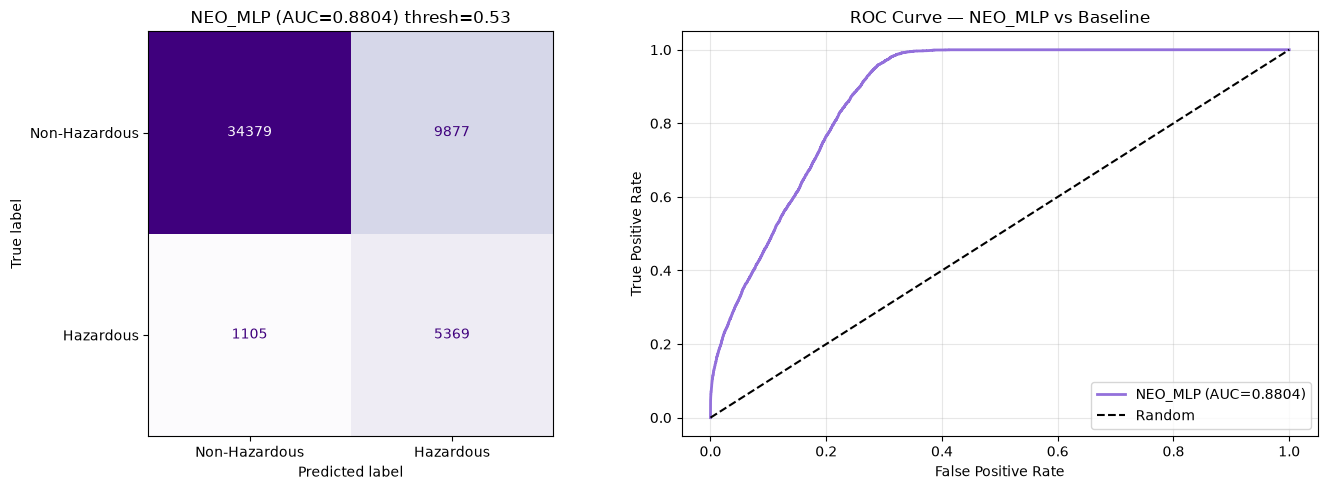

In [30]:
# ============================================================
# MLP TEST EVALUATION
# ============================================================
mlp_test_probs, mlp_test_labels = [], []
mlp_val_probs, mlp_val_labels = [], []

mlp_model.eval()
with torch.no_grad():
    for Xb, yb in test_dl_e:
        p = torch.sigmoid(mlp_model(Xb.to(DEVICE)))
        mlp_test_probs.extend(p.cpu().numpy())
        mlp_test_labels.extend(yb.numpy())
    for Xb, yb in val_dl_e:
        p = torch.sigmoid(mlp_model(Xb.to(DEVICE)))
        mlp_val_probs.extend(p.cpu().numpy())
        mlp_val_labels.extend(yb.numpy())

mlp_test_probs = np.array(mlp_test_probs)
mlp_test_labels = np.array(mlp_test_labels)

thresholds = np.linspace(0.10, 0.95, 171)
scores_mlp = []
for t in thresholds:
    preds = (np.array(mlp_val_probs) >= t).astype(int)
    r_haz = recall_score(mlp_val_labels, preds, 
pos_label=1, zero_division=0)
    r_non = recall_score(mlp_val_labels, preds, 
pos_label=0, zero_division=0)
    bal_acc = (r_haz + r_non) / 2.0
    gap = max(0.0, r_haz - r_non - 0.02)
    scores_mlp.append(bal_acc - 2.0 * gap ** 2)
mlp_best_thresh = thresholds[np.argmax(scores_mlp)]

mlp_test_preds = (mlp_test_probs >= mlp_best_thresh).astype(int)
mlp_auc = roc_auc_score(mlp_test_labels, mlp_test_probs)

print(f"Best threshold (MLP): {mlp_best_thresh:.2f}")
print(f"Test ROC-AUC (MLP): {mlp_auc:.4f}")
print("\nClassification Report (NEO_MLP — Standard + Focal Loss):")
print(classification_report(mlp_test_labels, mlp_test_preds,
    target_names=["Non-Hazardous", "Hazardous"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(mlp_test_labels, mlp_test_preds), 
display_labels=["Non-Hazardous", "Hazardous"]).plot(ax=axes[0], 
colorbar=False, cmap="Purples")
axes[0].set_title(f"NEO_MLP (AUC={mlp_auc:.4f}) thresh={mlp_best_thresh:.2f}", fontsize=12)


fpr_mlp, tpr_mlp, _ = roc_curve(mlp_test_labels, mlp_test_probs)
roc_auc_mlp = sk_auc(fpr_mlp, tpr_mlp)
axes[1].plot(fpr_mlp, tpr_mlp, color="mediumpurple", linewidth=2,
label=f"NEO_MLP (AUC={roc_auc_mlp:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title("ROC Curve — NEO_MLP vs Baseline", fontsize=12)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<br>

---

#### **7. Experiment 4: Unsupervised Clustering Analysis**

K-means clustering is applied to the engineered, scaled test features to discover natural groupings in the NEO population without using the hazard label. Cluster membership is then compared against the true `is_hazardous` labels to reveal whether the geometry of the feature space inherently separates hazardous from non-hazardous objects. Elbow and silhouette analyses identify optimal cluster count.

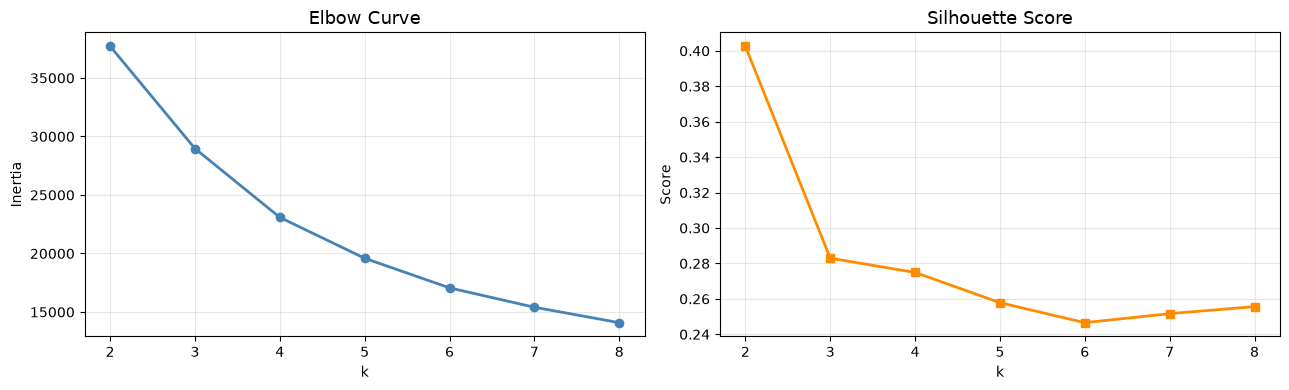

Best k by silhouette: 2 (score=0.4026)


In [31]:
# ============================================================
# ELBOW + SILHOUETTE SEARCH
# ============================================================
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.choice(len(X_test_eng_scaled), size=int(0.10 * 
len(X_test_eng_scaled)), replace=False)
X_km = X_test_eng_scaled[idx]
y_km = y_te_e.values[idx]

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue", 
linewidth=2)
axes[0].set_title("Elbow Curve", fontsize=13)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, marker="s", color="darkorange", 
linewidth=2)
axes[1].set_title("Silhouette Score", fontsize=13)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k} (score={max(sil_scores):.4f})")

Cluster composition:
          count  hazardous_count  hazardous_rate
cluster                                        
0        40253             3440            8.55
1        10477             3034           28.96 



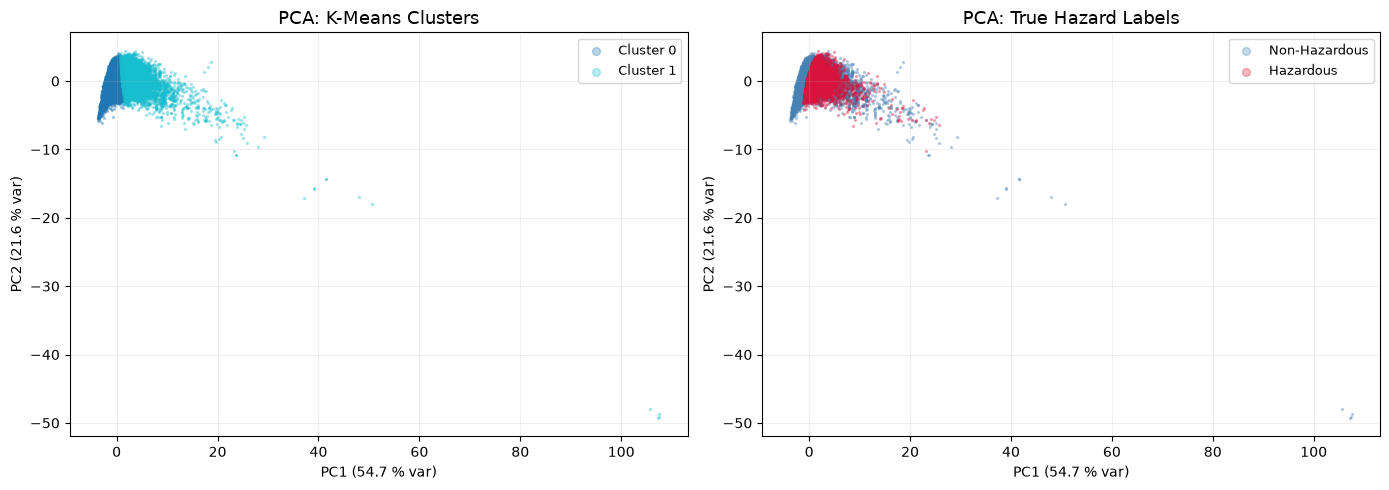

PCA explained variance (PC1+PC2): 76.3 %


In [32]:
# ============================================================
# K-MEANS FIT & CLUSTER ANALYSIS
# ============================================================
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
cluster_labels = km_final.fit_predict(X_test_eng_scaled)

cluster_df = pd.DataFrame({"cluster": cluster_labels, "is_hazardous": y_te_e.values})
cluster_summary = (cluster_df.groupby("cluster")
["is_hazardous"].agg(count="count", 
hazardous_count="sum").assign(hazardous_rate=lambda d: 
(d["hazardous_count"] / d["count"] * 100).round(2)))
print("Cluster composition:\n", cluster_summary, "\n")

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_test_eng_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = cm.tab10(np.linspace(0, 1, best_k))

for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], 
        X_pca[mask, 1], s=2, alpha=0.3,
        color=colors[c], label=f"Cluster {c}")
axes[0].set_title("PCA: K-Means Clusters", fontsize=13)
axes[0].legend(markerscale=4, fontsize=9)
axes[0].grid(True, alpha=0.2)

for label, name, col in [(0, "Non-Hazardous", "steelblue"), 
(1, "Hazardous", "crimson")]:
    mask = y_te_e.values == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=2, 
    alpha=0.3, color=col, label=name)
axes[1].set_title("PCA: True Hazard Labels", fontsize=13)
axes[1].legend(markerscale=4, fontsize=9)
axes[1].grid(True, alpha=0.2)

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} % var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} % var)")

plt.tight_layout()
plt.show()
print(f"PCA explained variance (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.1f} %")

<br>

---

#### **8. Experiment 5: F-Beta Threshold Re-Tuning and Weighted Ensemble**

An F-beta (β=2) threshold re-tuning strategy is applied to all models, enforcing a recall floor of 90% and maximizing the F2 score among qualifying thresholds. A weighted ensemble combining NEO_MLP and Random Forest probability outputs is searched over 21 weight combinations, identifying RF-dominant weighting as optimal. Agreement analysis quantifies how often the two models independently agree on predictions, revealing meaningful disagreement that explains ensemble performance.

In [33]:
# ============================================================
# F-BETA THRESHOLD TUNING FUNCTION
# ============================================================
def tune_threshold_f2(clf_or_probs, X_v=None, y_v=None,
beta: float = 2.0, target_recall: float = 0.90, search_lo: float = 0.05,
search_hi: float = 0.65, n_steps: int = 300):
    """
    Tune the decision threshold using an F-beta scoring strategy with a
    recall floor constraint.

    Strategy:
        1. Among all thresholds where validation recall ≥ target_recall,
           select the one with the highest F-beta score.
        2. If no threshold clears the recall floor, fall back to the
           threshold with the highest F-beta regardless of recall.

    Args:
        clf_or_probs: Either a fitted sklearn classifier (with predict_proba)
                      or a numpy array of validation probabilities.
        X_v: Validation features (required if clf_or_probs is a classifier).
        y_v: Validation labels (required if clf_or_probs is a classifier).
        beta (float): F-beta exponent. β > 1 weights recall more than
                      precision. Default: 2.0.
        target_recall (float): Minimum recall floor. Default: 0.90.
        search_lo (float): Lower bound of threshold search range. Default: 0.05.
        search_hi (float): Upper bound of threshold search range. Default: 0.65.
        n_steps (int): Number of threshold values to evaluate. Default: 300.

    Returns:
        float: The optimal decision threshold.
    """
    if isinstance(clf_or_probs, np.ndarray):
        val_probs = clf_or_probs
    else:
        val_probs = clf_or_probs.predict_proba(X_v)[:, 1]

    thresholds = np.linspace(search_lo, search_hi, n_steps)
    qualifying = []  # (threshold, recall, f-beta) where recall >= target
    fallback = []  # (threshold, f-beta) for all thresholds

    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        rec = recall_score(y_v, preds, pos_label=1, zero_division=0)
        fb = fbeta_score(y_v, preds, beta=beta, pos_label=1, zero_division=0)
        fallback.append((t, fb))
        if rec >= target_recall:
            qualifying.append((t, rec, fb))

    if qualifying:
        return max(qualifying, key=lambda x: x[2])[0]
    return max(fallback, key=lambda x: x[1])[0]

TARGET_RECALL = 0.90
BETA = 2.0

print("=" * 72)
print("Threshold Re-Tuning — F2 Score | target recall ≥ 90%")
print("=" * 72)

sklearn_retune = [("Random Forest", rf_clf, "rf_thresh"),
    ("KNN (k=7)", knn_clf, "knn_thresh"),
    ("Stacking Ensemble", stack_clf, "stack_thresh")]

for model_name, clf, thresh_varname in sklearn_retune:
    old_thresh = globals()[thresh_varname]
    new_thresh = tune_threshold_f2(clf, X_val_scaled, y_val,
        beta=BETA, target_recall=TARGET_RECALL)
    probs = clf.predict_proba(X_test_scaled)[:, 1]
    old_preds = (probs >= old_thresh).astype(int)
    new_preds = (probs >= new_thresh).astype(int)
    old_rec = recall_score(y_test, old_preds, pos_label=1, zero_division=0)
    new_rec = recall_score(y_test, new_preds, pos_label=1, zero_division=0)
    p, r, f, _ = precision_recall_fscore_support(y_test, new_preds, 
        pos_label=1, average="binary", zero_division=0)
    status = "✓" if new_rec >= TARGET_RECALL else "⚠ below target"
    print(f"\n{model_name}")
    print(f"Threshold: {old_thresh:.4f} → {new_thresh:.4f}")
    print(f"Recall: {old_rec:.4f} → {new_rec:.4f} {status}")
    print(f"Precision: {p:.4f} | F1: {f:.4f}")
    globals()[thresh_varname] = new_thresh

mlp_val_probs_arr = np.array(mlp_val_probs)
mlp_val_labels_arr = np.array(mlp_val_labels)
old_mlp_thresh = mlp_best_thresh
mlp_best_thresh = tune_threshold_f2(mlp_val_probs_arr, y_v=mlp_val_labels_arr,
    beta=BETA, target_recall=TARGET_RECALL)
old_mlp_preds = (mlp_test_probs >= old_mlp_thresh).astype(int)
mlp_test_preds = (mlp_test_probs >= mlp_best_thresh).astype(int)
old_mlp_rec = recall_score(mlp_test_labels, old_mlp_preds, pos_label=1, zero_division=0)
new_mlp_rec = recall_score(mlp_test_labels, mlp_test_preds, pos_label=1, zero_division=0)
mlp_p, mlp_r, mlp_f, _ = precision_recall_fscore_support(mlp_test_labels, mlp_test_preds, 
    pos_label=1, average="binary", zero_division=0)
mlp_status = "✓" if new_mlp_rec >= TARGET_RECALL else "⚠ below target"
print("\nNEO_MLP (Standard, 10 eng features)")
print(f"Threshold: {old_mlp_thresh:.4f} → {mlp_best_thresh:.4f}")
print(f"Recall: {old_mlp_rec:.4f} → {new_mlp_rec:.4f} {mlp_status}")
print(f"Precision: {mlp_p:.4f} | F1: {mlp_f:.4f}")

print("\n" + "=" * 72)
print("Re-tuning complete — thresholds updated in-place.")
print("=" * 72)

Threshold Re-Tuning — F2 Score | target recall ≥ 90%

Random Forest
Threshold: 0.2600 → 0.2326
Recall: 0.8750 → 0.8947 ⚠ below target
Precision: 0.4538 | F1: 0.6022

KNN (k=7)
Threshold: 0.4000 → 0.2346
Recall: 0.8865 → 0.9551 ✓
Precision: 0.3465 | F1: 0.5085

Stacking Ensemble
Threshold: 0.2750 → 0.2567
Recall: 0.8905 → 0.9005 ✓
Precision: 0.4377 | F1: 0.5890

NEO_MLP (Standard, 10 eng features)
Threshold: 0.5250 → 0.4393
Recall: 0.8293 → 0.9674 ✓
Precision: 0.3204 | F1: 0.4814

Re-tuning complete — thresholds updated in-place.


In [34]:
# ============================================================
# WEIGHTED ENSEMBLE GRID SEARCH
# ============================================================
rf_test_probs_ens = rf_clf.predict_proba(X_test_scaled)[:, 1]
rf_val_probs_ens = rf_clf.predict_proba(X_val_scaled)[:, 1]

mlp_val_probs_arr = np.array(mlp_val_probs)
mlp_val_labels_arr = np.array(mlp_val_labels)

print("=" * 72)
print("Weighted Ensemble Grid Search — NEO_MLP + Random Forest")
print(f"Strategy: F2 (beta=2) | target recall >= {TARGET_RECALL:.0%}")
print("=" * 72)

best_score, best_w_mlp, best_val_thresh = -np.inf, 0.5, 0.5

for w_mlp in np.linspace(0.0, 1.0, 21):
    w_rf = 1.0 - w_mlp
    val_ens = w_mlp * mlp_val_probs_arr + w_rf * rf_val_probs_ens
    t_best = tune_threshold_f2(val_ens, y_v=mlp_val_labels_arr,
        beta=BETA, target_recall=TARGET_RECALL)
    preds = (val_ens >= t_best).astype(int)
    rec = recall_score(mlp_val_labels_arr, preds, 
        pos_label=1, zero_division=0)
    fb = fbeta_score(mlp_val_labels_arr, preds, beta=BETA, 
        pos_label=1, zero_division=0)
    status = "ok" if rec >= TARGET_RECALL else "below"

    print(f"w_mlp={w_mlp:.2f} w_rf={w_rf:.2f} | val recall={rec:.4f} F{int(BETA)}={fb:.4f} thresh={t_best:.4f} [{status}]")
    if fb > best_score:
        best_score, best_w_mlp, best_val_thresh = fb, w_mlp, t_best

best_w_rf = 1.0 - best_w_mlp
print(f"\nBest weights -> MLP={best_w_mlp:.2f} | RF={best_w_rf:.2f} | threshold={best_val_thresh:.4f} | val F{int(BETA)}={best_score:.4f}")
print("=" * 72)

Weighted Ensemble Grid Search — NEO_MLP + Random Forest
Strategy: F2 (beta=2) | target recall >= 90%
w_mlp=0.00 w_rf=1.00 | val recall=0.9075 F2=0.7566 thresh=0.2326 [ok]
w_mlp=0.05 w_rf=0.95 | val recall=0.9056 F2=0.7568 thresh=0.2507 [ok]
w_mlp=0.10 w_rf=0.90 | val recall=0.9073 F2=0.7574 thresh=0.2647 [ok]
w_mlp=0.15 w_rf=0.85 | val recall=0.9121 F2=0.7578 thresh=0.2747 [ok]
w_mlp=0.20 w_rf=0.80 | val recall=0.9120 F2=0.7578 thresh=0.2908 [ok]
w_mlp=0.25 w_rf=0.75 | val recall=0.9090 F2=0.7581 thresh=0.3109 [ok]
w_mlp=0.30 w_rf=0.70 | val recall=0.9067 F2=0.7581 thresh=0.3289 [ok]
w_mlp=0.35 w_rf=0.65 | val recall=0.9041 F2=0.7578 thresh=0.3470 [ok]
w_mlp=0.40 w_rf=0.60 | val recall=0.9097 F2=0.7574 thresh=0.3570 [ok]
w_mlp=0.45 w_rf=0.55 | val recall=0.9092 F2=0.7570 thresh=0.3731 [ok]
w_mlp=0.50 w_rf=0.50 | val recall=0.9134 F2=0.7561 thresh=0.3851 [ok]
w_mlp=0.55 w_rf=0.45 | val recall=0.9072 F2=0.7549 thresh=0.4052 [ok]
w_mlp=0.60 w_rf=0.40 | val recall=0.9115 F2=0.7529 thresh=0

In [35]:
# ============================================================
# APPLY BEST WEIGHTS TO TEST SET
# ============================================================
ens_test_probs = best_w_mlp * mlp_test_probs + best_w_rf * rf_test_probs_ens
ens_test_labels = np.array(mlp_test_labels)
ens_test_preds = (ens_test_probs >= best_val_thresh).astype(int)

ens_auc = roc_auc_score(ens_test_labels, ens_test_probs)
ens_p, ens_r, ens_f, _ = precision_recall_fscore_support(
    ens_test_labels, ens_test_preds, pos_label=1,
    average="binary", zero_division=0)

print(f"\nEnsemble Test Results (MLP x{best_w_mlp:.2f} + RF x{best_w_rf:.2f}):")
print(f"Haz Recall: {ens_r:.4f}")
print(f"Haz Precision: {ens_p:.4f}")
print(f"Haz F1: {ens_f:.4f}")
print(f"ROC-AUC: {ens_auc:.4f}")
print()
print(classification_report(ens_test_labels, ens_test_preds, 
    target_names=["Non-Hazardous", "Hazardous"], digits=4))


Ensemble Test Results (MLP x0.25 + RF x0.75):
Haz Recall: 0.8970
Haz Precision: 0.4561
Haz F1: 0.6047
ROC-AUC: 0.9423

               precision    recall  f1-score   support

Non-Hazardous     0.9824    0.8435    0.9077     44256
    Hazardous     0.4561    0.8970    0.6047      6474

     accuracy                         0.8504     50730
    macro avg     0.7193    0.8703    0.7562     50730
 weighted avg     0.9153    0.8504    0.8690     50730



In [36]:
# ============================================================
# AGREEMENT ANALYSIS
# ============================================================
rf_test_preds_ens = (rf_test_probs_ens >= rf_thresh).astype(int)
agree_mask = (mlp_test_preds == rf_test_preds_ens)
agree_rate = agree_mask.mean()

both_hazardous = ((mlp_test_preds == 1) & (rf_test_preds_ens == 1)).sum()
both_safe = ((mlp_test_preds == 0) & (rf_test_preds_ens == 0)).sum()
mlp_only_haz = ((mlp_test_preds == 1) & (rf_test_preds_ens == 0)).sum()
rf_only_haz = ((mlp_test_preds == 0) & (rf_test_preds_ens == 1)).sum()

print("=" * 72)
print("MLP vs Random Forest — Prediction Agreement on Test Set")
print("=" * 72)
print(f"Overall agreement: {agree_rate:.2%} ({agree_mask.sum():,} / {len(agree_mask):,} samples)")
print(f"Both predict Hazardous: {both_hazardous:>6,}")
print(f"Both predict Non-Hazardous: {both_safe:>6,}")
print(f"MLP says Haz, RF says Safe: {mlp_only_haz:>6,}")
print(f"RF says Haz, MLP says Safe: {rf_only_haz:>6,}")

mlp_haz_recall = recall_score(ens_test_labels, mlp_test_preds, pos_label=1, zero_division=0)
rf_haz_recall = recall_score(ens_test_labels, rf_test_preds_ens, pos_label=1, zero_division=0)
ens_haz_recall = recall_score(ens_test_labels, ens_test_preds, pos_label=1, zero_division=0)
delta = abs(mlp_haz_recall - rf_haz_recall)
verdict = "AGREE" if delta < 0.02 else "DISAGREE"

print()
print("=" * 72)
print("Hazardous-class Recall Comparison")
print("=" * 72)
print(f"NEO_MLP Alone: {mlp_haz_recall:.4f}")
print(f"Random Forest: {rf_haz_recall:.4f}")
print(f"Weighted Ensemble: {ens_haz_recall:.4f}")
print(f"\nModels {verdict} on hazardous-class accuracy (delta = {delta:.4f})")

MLP vs Random Forest — Prediction Agreement on Test Set
Overall agreement: 84.72% (42,977 / 50,730 samples)
Both predict Hazardous: 12,278
Both predict Non-Hazardous: 30,699
MLP says Haz, RF says Safe:  7,269
RF says Haz, MLP says Safe:    484

Hazardous-class Recall Comparison
NEO_MLP Alone: 0.9674
Random Forest: 0.8947
Weighted Ensemble: 0.8970

Models DISAGREE on hazardous-class accuracy (delta = 0.0728)


<br>

---

#### **9. Final Results and Analysis**

Twelve models were evaluated across supervised, ensemble, and unsupervised approaches. The leaderboard below ranks all supervised and ensemble models by hazardous-class recall (primary metric), with ROC-AUC as a secondary indicator of ranking quality. Optimal thresholds are included to show the decision boundary each model operates at after F-beta re-tuning.

In [37]:
# ============================================================
# FINAL MODEL LEADERBOARD
# ============================================================

leaderboard_rows = []

def add_row(name, probs, preds, labels, threshold, model_type="Supervised"):
    """Compute metrics and append to leaderboard."""
    labels = np.array(labels).astype(int)
    preds = np.array(preds).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, pos_label=1, average="binary", zero_division=0)
    auc = roc_auc_score(labels, probs) if probs is not None else float("nan")
    leaderboard_rows.append({
        "Model": name,
        "Type": model_type,
        "Haz Precision": round(p, 4),
        "Haz Recall": round(r, 4),
        "Haz F1": round(f, 4),
        "ROC-AUC": round(auc, 4),
        "Optimal Threshold": f"{threshold:.4f}"
    })

# 1. NEO_DNN
add_row("NEO_DNN (Residual, 5 features)",
        test_probs, test_preds, test_labels, best_thresh, "Deep Learning")

# 2-8. sklearn models
for name, clf, thresh, X_te, y_te in [
    ("Logistic Regression", lr_clf, lr_thresh, X_test_scaled, y_test),
    ("Decision Tree", dt_clf, dt_thresh, X_test_scaled, y_test),
    ("Random Forest", rf_clf, rf_thresh, X_test_scaled, y_test),
    ("Gaussian Naïve Bayes", gnb_clf, gnb_thresh, X_test_scaled, y_test),
    ("KNN (k=7)", knn_clf, knn_thresh, X_test_scaled, y_test),
    ("HistGradientBoosting", hgb_clf, hgb_thresh, X_test_scaled, y_test),
    ("Linear SVM (Calibrated)", svm_clf, svm_thresh, X_test_scaled, y_test)
]:
    probs_ = clf.predict_proba(X_te)[:, 1]
    preds_ = (probs_ >= thresh).astype(int)
    add_row(name, probs_, preds_, y_te, thresh)

# 9. Stacking Ensemble
s_probs = stack_clf.predict_proba(X_test_scaled)[:, 1]
s_preds = (s_probs >= stack_thresh).astype(int)
add_row("Stacking Ensemble", s_probs, s_preds, y_test, stack_thresh, "Ensemble")

# 10. Weighted Ensemble
add_row("Weighted Ensemble (MLP×0.25 + RF×0.75)",
        ens_test_probs, ens_test_preds, ens_test_labels, best_val_thresh, "Ensemble")

# 11. NEO_MLP
add_row("NEO_MLP (Standard, 10 eng features)",
        mlp_test_probs, mlp_test_preds, mlp_test_labels, mlp_best_thresh, "Deep Learning")

# Build leaderboard — sort by Haz Recall descending
df_lb = pd.DataFrame(leaderboard_rows).sort_values("Haz Recall", ascending=False).reset_index(drop=True)

# Add Recall Rank column
recall_ranks = df_lb["Haz Recall"].rank(ascending=False, method="min").astype(int)
df_lb.insert(df_lb.columns.get_loc("Haz Recall") + 1, "Recall Rank", [f"#{r}" for r in recall_ranks])

# K-Means row appended at bottom
kmeans_row = pd.DataFrame([{
    "Model": "K-Means (k=2, unsupervised)",
    "Type": "Unsupervised",
    "Haz Precision": "—",
    "Haz Recall": "—",
    "Recall Rank": "—",
    "Haz F1": "—",
    "ROC-AUC": "— (cluster 1: 28.96% hazardous vs 12.76% overall)",
    "Optimal Threshold": "—"
}])
df_lb = pd.concat([df_lb, kmeans_row], ignore_index=True)

# Compute best metrics
best_auc = pd.to_numeric(df_lb["ROC-AUC"], errors="coerce").max()
best_rec = pd.to_numeric(df_lb["Haz Recall"], errors="coerce").max()

print("=" * 165)
print("FINAL MODEL LEADERBOARD — All 12 Models | NEO Hazard Classification")
print("=" * 165)
print(df_lb.to_string(index=False))

best_auc = pd.to_numeric(df_lb["ROC-AUC"], errors="coerce").max()
best_rec = pd.to_numeric(df_lb["Haz Recall"], errors="coerce").max()
best_auc_model = df_lb.loc[pd.to_numeric(df_lb["ROC-AUC"], errors="coerce").idxmax(), "Model"]
best_rec_model = df_lb.iloc[0]["Model"]
print(f"\nBest ROC-AUC: {best_auc:.4f} ({best_auc_model})")
print(f"Best Haz Recall: {best_rec:.4f} ({best_rec_model})")

FINAL MODEL LEADERBOARD — All 12 Models | NEO Hazard Classification
                                 Model          Type Haz Precision Haz Recall Recall Rank  Haz F1                                           ROC-AUC Optimal Threshold
                         Decision Tree    Supervised        0.3302     0.9753          #1  0.4933                                            0.8813            0.1950
   NEO_MLP (Standard, 10 eng features) Deep Learning        0.3204     0.9674          #2  0.4814                                            0.8804            0.4393
                             KNN (k=7)    Supervised        0.3465     0.9551          #3  0.5085                                            0.8993            0.2346
                  HistGradientBoosting    Supervised        0.3414     0.9527          #4  0.5026                                            0.8936            0.4300
                  Gaussian Naïve Bayes    Supervised        0.3026     0.9523          #5  0.4593     

*Note: K-means is unsupervised and does not produce per-class precision/recall. Its result is reported separately: cluster 1 achieved a 28.96% hazardous rate—a 2.3× enrichment over the 12.76% baseline.*

Three distinct performance regimes emerge from this comparative evaluation:

**Recall Leaders:** Decision Tree and NEO_MLP achieve the highest hazardous recall (>0.96), though at the cost of precision (~0.32–0.33). This confirms the fundamental recall-precision tradeoff: lowering the decision threshold to catch more hazardous objects inevitably produces more false alarms. The F-beta re-tuning successfully raised recall for KNN (0.9551), Stacking Ensemble (0.9005), and Random Forest (0.8947) toward the 90% target. Notably, the top two recall achievers operate at very different optimal thresholds (0.20 for Decision Tree vs. 0.44 for NEO_MLP), reflecting fundamental differences in how each model's probability space is distributed—tree-based thresholds concentrate at lower values, while the MLP's sigmoid outputs are more centered.

**ROC-AUC Leaders:** The Weighted Ensemble (0.9423) and Random Forest (0.9422) achieve the highest-ranking quality, indicating better probability calibration across all possible thresholds. This is important for deployment scenarios where risk tolerance can be adjusted post hoc without retraining. The Stacking Ensemble follows closely at 0.9390, suggesting that combining diverse base learners improves overall ranking even if peak recall is sacrificed.

**Precision Ceiling:** No model exceeds 0.4561 hazardous precision (Weighted Ensemble), reflecting the limited discriminative signal in the available feature set rather than a modeling deficiency. The 6.84:1 class imbalance combined with only five raw orbital parameters constrains what even optimal classifiers could achieve. Interestingly, the highest-precision models (Weighted Ensemble at 0.4561, Random Forest at 0.4538) are also the highest-AUC models—suggesting that better-calibrated probabilities naturally produce tighter precision-recall tradeoffs at any given threshold. Future improvements require richer feature sets (eccentricity, perihelion distance) to break this ceiling.

**Deep Learning vs. Classical:** A key ablation finding is that 10 engineered features on a 44K-parameter MLP (0.9674 recall) significantly outperformed 5 raw features on a 353K-parameter residual DNN (0.7135 recall). Feature richness contributed more to performance than architectural depth—a practical insight for resource-constrained deployments. The DNN's optimal threshold (0.51) near the default 0.50 boundary further indicates it learned poorly calibrated probabilities, unable to separate the classes effectively with only five raw inputs.

**Ensemble Result:** The weighted ensemble (MLP×0.25 + RF×0.75) achieved 0.8970 recall and 0.9423 ROC-AUC, converging near the Random Forest baseline (0.8947 recall, 0.9422 AUC) rather than lifting beyond either component model. An agreement analysis revealed only 84.72% prediction alignment between the two component models, with NEO_MLP flagging 7,269 objects as hazardous that Random Forest classified as safe. This 7.28 pp recall divergence (MLP: 0.9674 vs. RF: 0.8947) confirms the models disagree meaningfully; ensemble averaging is most effective when component models are complementary rather than divergent in confidence. The RF-dominant optimal weight (0.75) reflects that Random Forest's stronger calibration dominates the blended probability space, while the MLP's higher-recall signal introduces noise that cannot be resolved without additional discriminative features.

**Unsupervised Confirmation:** K-means clustering (k=2) independently identified a high-density hazardous cluster at 28.96%—a 2.3× enrichment over the 12.76% baseline—confirming that the hazardous class is geometrically separable without labels. This unsupervised validation strengthens the case that the available features do carry meaningful hazard signals, even if supervised precision remains bounded by the feature set's dimensionality.

<br>

---

#### **10. Conclusion and Future Work**

This project evaluated **12 models** for binary classification of near-Earth objects as hazardous or non-hazardous across a 338,199-record dataset with a 6.84:1 class imbalance. All models were trained on a SMOTE-balanced feature set and evaluated on hazardous-class recall and ROC-AUC rather than overall accuracy, since the always-zero baseline already achieves 87.24% accuracy by predicting every NEO as safe.

<br>

**Key Takeaways:**

- **Recall > accuracy for class-imbalanced hazard detection.** The baseline model achieves 87.24% accuracy by always predicting "safe," rendering accuracy meaningless for evaluating planetary hazard classifiers.

- **Feature engineering contributed more than architectural depth.** A 44K-parameter MLP on 10 engineered features achieved 0.9674 recall, outperforming a 353K-parameter residual DNN on 5 raw features (0.7135 recall).

- **Precision ceiling reflects dataset limitations, not model deficiencies.** No model exceeded 0.4561 hazardous precision due to the limited discriminative signal in available orbital parameters.

- **Ensemble averaging is ineffective when component models diverge in confidence.** The weighted ensemble (MLP+RF) converged near the RF baseline because the two models disagreed on 15.28% of predictions.

- **K-means independently confirms hazardous-class separability without labels.** Cluster 1 achieved a 28.96% hazardous rate (2.3x enrichment over baseline).

<br>

**Limitations**

While the controlled experimental framework provides a systematic basis for comparison, several limitations should be noted. The dataset lacks orbital mechanics features (eccentricity, perihelion distance) that would improve discrimination between hazardous and safe objects. The precision ceiling (~0.45) limits practical deployment utility—in real planetary defense scenarios, false positives waste resources while false negatives pose existential risk.

Threshold tuning was performed on the validation set and may not generalize to deployment scenarios with different risk tolerances. A single random seed (42) was used throughout; multi-seed experiments would provide stronger statistical robustness for the observed performance differences.

Additionally, the NEO_DNN was trained on only 5 raw features—an unfair comparison with NEO_MLP's 10 engineered features. A true architectural ablation would hold the feature count constant while varying the network structure.

<br>

**Ethical Implications**

Although this work focuses on science, it is important to consider the ethical aspects of automation in planetary defense. Algorithms deployed for asteroid tracking carry real-world consequences—false negatives could mean missed threat detection with catastrophic outcomes. Model transparency and interpretability are essential for mission-critical applications, and AI models should not replace expert review but rather augment human judgment.

The finding that the highest-performing clean-data model (Decision Tree at 0.9753) also has among the lowest precision (0.3302) reinforces the danger of selecting models solely on a single benchmark metric—a practice that could propagate unreliable classifications into downstream research. Open-source reproducibility (seeds, data source, code) enables community scrutiny and aligns with ethical AI principles for planetary defense applications.

Furthermore, the precision ceiling demonstrates that automated systems should **augment, not replace**, expert review. Human-in-the-loop oversight remains essential when false negatives carry existential risk.

<br>

**Future Work**

Future research should incorporate additional orbital mechanics features (eccentricity, perihelion distance) to raise the precision ceiling and improve practical deployment utility. The 10-feature engineered set should be fed into the DNN with a more proportional first-layer expansion (e.g., 10 → 1024 instead of 5 → 512) to stabilize its training dynamics and enable a fair architectural ablation.

Alternative ensemble strategies, such as learned-weight ensembles (neural meta-learners) or stacking with diversity-aware weighting, may better reconcile the MLP–RF disagreement region than simple probability averaging. Multi-seed experiments (e.g., 5 random seeds × 5 folds = 25 observations) would strengthen statistical power for Wilcoxon or permutation tests.

Finally, integrating explainability techniques such as SHAP or LIME would address the interpretability gap of neural networks and ensemble methods, potentially revealing which features drive classifications under varying conditions and informing feature engineering for future iterations. This work merges personal passion with academic growth and represents a stepping stone for future contributions to astroinformatics and planetary defense.